### Persons in the geographical space

We present various methods of spatialising the birthplaces of our population.

The data was prepared using the queries [documented on this page](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da2-birth-places.sql)

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely import wkt

import scipy.stats as stats
import math

from geopandas.tools import sjoin
#from geodatasets import get_path

In [2]:
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import json

import numpy as np
import seaborn as sns
import math
import os

In [3]:
import warnings
warnings.filterwarnings('ignore')


In [4]:

import pprint
import csv


from shutil import copyfile


In [5]:
italy_filepath = 'geo_data/it_territories.geojson'
## dataframe GeoPandas
italy = gpd.read_file(italy_filepath)
italy.head()

,reg_name,reg_istat_code_num,reg_istat_code,geometry
0,Piemonte,1,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,Valle d'Aosta/Vallée d'Aoste,2,02,"POLYGON ((7.73455 45.92365, 7.7359 45.92744, 7..."
2,Lombardia,3,03,"MULTIPOLYGON (((8.57964 45.75172, 8.57532 45.7..."
3,Trentino-Alto Adige/Südtirol,4,04,"POLYGON ((12.01396 46.55091, 12.01376 46.55077..."
4,Veneto,5,05,"POLYGON ((10.63538 45.53543, 10.63228 45.56846..."


### Basic GIS notions

* [Geographic information system - GIS](https://en.wikipedia.org/wiki/Geographic_information_system)
* [Geoid](https://en.wikipedia.org/wiki/Geoid)
* [Earth ellipsoid](https://en.wikipedia.org/wiki/Earth_ellipsoid): WGS84
* [Spatial reference system - SRS/CRS](https://en.wikipedia.org/wiki/Spatial_reference_system)
* [EPSG Geodetic Parameter Dataset](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset): EPSG:4326, EPSG:3857, EPSG:9989

In [6]:
### Inspect the projection
pprint.pprint(italy.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



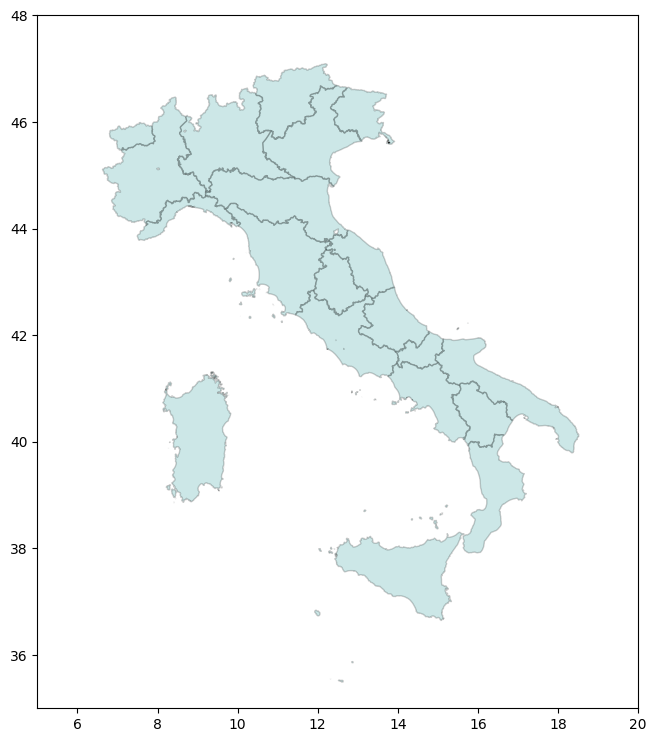

In [7]:
### Draw the map of Italian regions

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html


ax = italy.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(12,9))

# If we want to exclude the Antarctic region
ax.set_xlim(5,20)
ax.set_ylim(35, 48)


plt.show()



## Import the data

The data is available in the da_data directory and was prepared using the query [documented on this page](../../documentation/wikidata/data-analysis/da1-distribution-of-births-in-time.md)

In [8]:
## create variable declaring the path to the data
path_to_data = 'da2-birth-place.csv'

In [9]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)
df_p.columns = ['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace',
                'geometry','uriPlace']

## first rows of the dataframe
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q104599786,Maria Cristina Messa,1961,femmina,Monza,POINT(9.273611 45.583611),http://www.wikidata.org/entity/Q6252
1,http://www.wikidata.org/entity/Q105296748,Daniele Franco,1953,maschio,Trichiana,POINT(12.134445 46.074444),http://www.wikidata.org/entity/Q40468
2,http://www.wikidata.org/entity/Q105320865,Patrizio Bianchi,1952,maschio,Copparo,POINT(11.833333 44.900000),http://www.wikidata.org/entity/Q95098
3,http://www.wikidata.org/entity/Q1053876,Randolfo Pacciardi,1899,maschio,Giuncarico,POINT(10.991945 42.906945),http://www.wikidata.org/entity/Q2456297
4,http://www.wikidata.org/entity/Q1055104,Pietro Lunardi,1939,maschio,Parma,POINT(10.328000 44.801472),http://www.wikidata.org/entity/Q2683


In [10]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      575 non-null    object
 1   labelPer    572 non-null    object
 2   birthYear   575 non-null    int64 
 3   gender      575 non-null    object
 4   labelPlace  575 non-null    object
 5   geometry    575 non-null    object
 6   uriPlace    575 non-null    object
dtypes: int64(1), object(6)
memory usage: 31.6+ KB


## Inspect the data


In [11]:
### Add column names and inspect length of dataframe

print('Number: ',len(df_p))
df_p.iloc[10:13,:]

Number:  575


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
10,http://www.wikidata.org/entity/Q1071031,Paolo Gentiloni,1954,maschio,Roma,POINT(12.482778 41.893056),http://www.wikidata.org/entity/Q220
11,http://www.wikidata.org/entity/Q1071053,Cesare Damiano,1948,maschio,Cuneo,POINT(7.550000 44.383333),http://www.wikidata.org/entity/Q5968
12,http://www.wikidata.org/entity/Q1071082,Barbara Pollastrini,1947,femmina,Darfo Boario Terme,POINT(10.186667 45.894444),http://www.wikidata.org/entity/Q104565


### Treat multiple birth places

Verify that persons are unique:
* are there some persons with multiple birth places, etc.?
  * If Pandas *is_unique* method: 'true' they are unique, so no multiple.
  * If 'false': multiple rows per person
* If you have multiple persons go back to the SQL part and clean up using GROUP BY -> MIN  

In [12]:
### Tests if the values in the column are unique
# If unique result : True (boolean value not string !)
is_unique=df_p.uriPer.is_unique
print(is_unique)

True


## Group and map birth places

"Well-known text (WKT) is a text markup language for representing vector geometry objects" ([Wikipedia](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry))

In [13]:
### Group and count the number of persons per birth place
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'size']
p_gr.sort_values('size', ascending=False).head()


,uriPlace,labelPlace,geometry,size
93,http://www.wikidata.org/entity/Q220,Roma,POINT(12.482778 41.893056),67
171,http://www.wikidata.org/entity/Q490,Milano,POINT(9.190000 45.466944),31
103,http://www.wikidata.org/entity/Q2634,Napoli,POINT(14.248611 40.835833),22
173,http://www.wikidata.org/entity/Q495,Torino,POINT(7.676111 45.079167),15
72,http://www.wikidata.org/entity/Q1891,Bologna,POINT(11.342778 44.493889),12


In [14]:
### Try first to convert WKT into Point Geometry
# using a geopandas feature
try:
    p_gr['geometry'] = p_gr['geometry'].apply(wkt.loads)
except Exception as e:
    print(e)

In [15]:
### there are wrong values in the data: find them
# all the rows where the geometry field does not contain the string 'POINT'
df_p.loc[~df_p.geometry.str.contains('POINT')]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace


In [16]:
### Drop the rows with the wrong value
df_p=df_p.loc[df_p.geometry.str.contains('POINT')]

In [17]:
### Re-do grouping after cleaning up
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'number']
p_gr.sort_values('number', ascending=False).head(2)


,uriPlace,labelPlace,geometry,number
93,http://www.wikidata.org/entity/Q220,Roma,POINT(12.482778 41.893056),67
171,http://www.wikidata.org/entity/Q490,Milano,POINT(9.190000 45.466944),31


In [18]:

### Create a dataframe with the POINT geometry
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_gdf = gpd.GeoDataFrame(
    p_gr, 
    ### Use this if no conversion before to geometry
    ## Cf. above:  p_gr['geometry'].apply(wkt.loads)
    geometry=gpd.GeoSeries.from_wkt(p_gr.geometry), 
    crs=4326
)

birth_gdf.sort_values('number', ascending=False).head(2)



,uriPlace,labelPlace,geometry,number
93,http://www.wikidata.org/entity/Q220,Roma,POINT (12.48278 41.89306),67
171,http://www.wikidata.org/entity/Q490,Milano,POINT (9.19 45.46694),31


In [19]:
### The Python class of the object changed 
# WKT strings are now points
print(p_gr.geometry.dtype, '->', birth_gdf.geometry.dtype)

object -> geometry


In [20]:
### Inspect the projection
pprint.pprint(birth_gdf.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



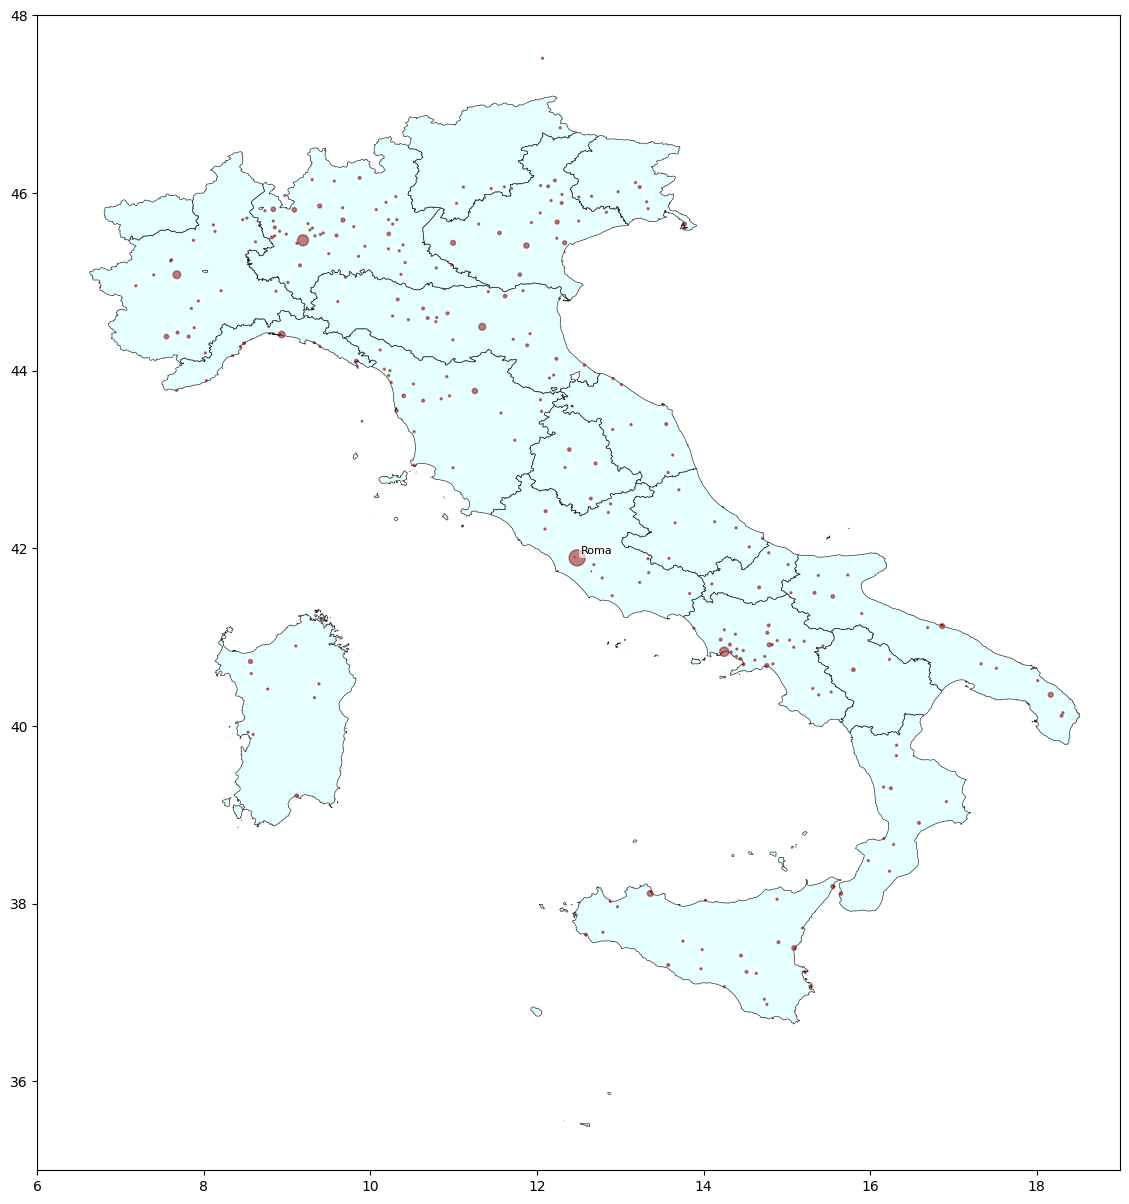

Done -> Mappa creata con it_territories.geojson


In [21]:
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. Carica il tuo file locale
italy_filepath = 'geo_data/it_territories.geojson'
italy = gpd.read_file(italy_filepath)

# 2. Setup del plot - Figsize ridotto per essere leggibile
fig, ax = plt.subplots(figsize=(20, 15))

# 3. Disegna la mappa dell'Italia dal tuo file
# Uso "LightCyan" come avevi nel codice originale
italy.plot(ax=ax, color="LightCyan", edgecolor="black", linewidth=0.5, alpha=0.8)

# 4. Imposta i limiti degli assi per inquadrare correttamente l'Italia
# Questi limiti assicurano che la visuale sia centrata sulla penisola
ax.set_xlim(6, 19)
ax.set_ylim(35, 48)

# 5. Plot dei tuoi dati (birth_gdf)
# Assicurati che birth_gdf sia già un GeoDataFrame con geometria Point
birth_gdf.plot(ax=ax, color="DarkRed", markersize=birth_gdf['number']*2, alpha=0.5)

# 6. Aggiunta delle etichette (Labels) filtrate per numero > 50
for _, row in birth_gdf[birth_gdf['number'] > 50].iterrows():
    # Otteniamo le coordinate x e y dalla geometria del punto
    x = row.geometry.x
    y = row.geometry.y
    
    ax.annotate(
        text=row['labelPlace'],
        xy=(x, y),
        xytext=(3, 3),              # piccolo spostamento per non coprire il punto
        textcoords="offset points",
        fontsize=8,
        color="Black",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.7
        )
    )

# 7. Salvataggio e mostrualizzazione
f_address = "images/birth_places_italy.png"
plt.savefig(f_address, dpi=300, bbox_inches='tight')
plt.show()

print('Done -> Mappa creata con it_territories.geojson')

## Experiment with different kinds of maps

In [22]:
birth_gdf.head(1)

,uriPlace,labelPlace,geometry,number
0,http://www.wikidata.org/entity/Q100113,Zocca,POINT (10.99041 44.34726),1


In [23]:
### Create columns for long / lat
birth_gdf['long'] = birth_gdf['geometry'].x
birth_gdf['lat'] = birth_gdf['geometry'].y
birth_gdf.head(1)

,uriPlace,labelPlace,geometry,number,long,lat
0,http://www.wikidata.org/entity/Q100113,Zocca,POINT (10.99041 44.34726),1,10.990407,44.347264


In [24]:
birth_gdf_plus1 = birth_gdf.loc[birth_gdf.number>1]
print(birth_gdf_plus1[["lat", "long"]].head(10))
print(birth_gdf_plus1[["lat", "long"]].describe())
print(birth_gdf_plus1.crs)

          lat       long
5   45.521389   9.592778
9   43.662500  10.632778
21  40.680556  14.759444
23  44.592500  10.687778
24  45.611958   8.851800
28  45.810250   9.086139
34  44.308056   8.481111
36  44.700000  10.633333
37  44.839167  11.617500
40  43.716667  10.400000
             lat       long
count  78.000000  78.000000
mean   42.404762  12.603864
std     4.182641   4.011957
min    15.333333   7.550000
25%    40.734236  10.244378
50%    43.689583  12.237776
75%    45.352154  14.507570
max    46.169720  38.916667
EPSG:4326


In [25]:
### We explore different ways of normalizing the data,
## i.e. diminishing the difference between high and low values
# p_size = [int(s/10+2) for s in birth_gdf_plus1['number']]
# p_size = [int(s) for s in birth_gdf_plus1['number']]
p_size = [(math.log(s)) for s in birth_gdf_plus1['number']]
max(p_size)

4.204692619390966

In [26]:

fig = px.scatter_map(
    birth_gdf_plus1, lat="lat", lon="long", size=p_size,
    hover_name="labelPlace", hover_data=["number"],
    opacity=0.8, zoom=3.5,
    center=dict(lon=8.5, lat=47),
    height=1000
)

fig.update_traces(marker=dict(color="GreenYellow", sizemin=0.2))

fig.update_layout(
    map=dict(
        style={
            "version": 8,
            "sources": {
                "usgs": {
                    "type": "raster",
                    "tiles": ["https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}"],
                    "tileSize": 256
                }
            },
            "layers": [{
                "id": "usgs-layer",
                "type": "raster",
                "source": "usgs"
            }]
        },
        center=dict(lon=8.5, lat=47),
        zoom=3.5
    )
)

#fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
f_address = "interactive_images/birth_places_geological_survey.html"
fig.write_html(f_address)
print('Done -> inspect picture')
# fig.show()
plt.close()

Done -> inspect picture


In [27]:
### Open the world regions ESRI file in geojson format (and not dataframe)
with open('geo_data/it_territories.geojson') as f:
    geojson = json.load(f)

geojson['features'][3]['properties']


{'reg_name': 'Trentino-Alto Adige/Südtirol',
 'reg_istat_code_num': 4,
 'reg_istat_code': '04'}

In [28]:
### 

p_size = [int(s/10+2) for s in birth_gdf_plus1['number']]

fig = px.scatter_map(birth_gdf_plus1, lat="lat", lon="long", size=p_size, 
                     hover_name="labelPlace", 
                        color_discrete_sequence=["DodgerBlue"],  zoom=3.5,
                        center=dict(lon=8.5, lat=47),height=600,
                        opacity=0.9)
fig.update_layout(
    map_style="white-bg",
    map_layers=[
        {
            "below": 'traces',
            "sourcetype": "geojson",
            "type":"line",
            "sourceattribution": "ESRI",
            "source": geojson,
            "line": {"width": 0.5},
        }
      ])

f_address = "interactive_images/birth_places_regions.html"
fig.write_html(f_address)
#fig.show()

### Plot the world as a sphere

In [29]:
### Plot on world as a sphere

lon = birth_gdf["long"]
lat= birth_gdf["lat"]
label= birth_gdf["labelPlace"]
size=[s/10 + 3 for s in birth_gdf["number"]]


# Create the figure
fig = go.Figure(data=go.Scattergeo(
    lon=lon,
    lat=lat,
    mode='markers+text',
    marker=dict(size=size,
                color='red'),
    hovertext=label,
    textposition='top center',
    hoverinfo='text',
    hoverlabel=dict(
        bgcolor='white',
        font_size=12,
        font_family='Arial'
    )
))

# Set the projection to orthogonal
fig.update_layout(
    width=800, 
    height=800,
    geo=dict(
        projection=dict(
            type='orthographic'
        )
    )
)

f_address = "interactive_images/birth_places_globus.html"
fig.write_html(f_address)
# Show the plot
#fig.show()

### Join regions and inspect

We use here spatial joins and associate a region to each place

In [30]:
### GeoPandas spatial join

w_birth_gdf= birth_gdf.sjoin(italy)
w_birth_gdf.iloc[[1,5,10]]

,uriPlace,labelPlace,geometry,number,long,lat,index_right,reg_name,reg_istat_code_num,reg_istat_code
1,http://www.wikidata.org/entity/Q100123,Calcinate,POINT (9.8003 45.6212),1,9.800300,45.621200,2,Lombardia,3,03
5,http://www.wikidata.org/entity/Q101685,Treviglio,POINT (9.59278 45.52139),2,9.592778,45.521389,2,Lombardia,3,03
10,http://www.wikidata.org/entity/Q103244,San Miniato,POINT (10.85 43.68333),1,10.850000,43.683333,8,Toscana,9,09


In [31]:
### Number of regions
print(len(italy))
italy.head(1)

20


,reg_name,reg_istat_code_num,reg_istat_code,geometry
0,Piemonte,1,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [32]:
### Count by region (sum number of each place in the region)
swb = w_birth_gdf.groupby(['reg_istat_code_num','reg_name'], as_index=False)['number'].sum()
#swb = swb.set_index('FID', drop=False)
print(len(swb))
swb.sort_values('number', ascending=False).head(24)


19


,reg_istat_code_num,reg_name,number
1,3,Lombardia,95
10,12,Lazio,80
13,15,Campania,60
17,19,Sicilia,42
3,5,Veneto,42
6,8,Emilia-Romagna,41
0,1,Piemonte,40
7,9,Toscana,30
14,16,Puglia,29
5,7,Liguria,21


In [33]:
### Find places in European Russia with most births 
w_birth_gdf.loc[w_birth_gdf.reg_istat_code_num==9].sort_values('number',ascending=False).head(2)

,uriPlace,labelPlace,geometry,number,long,lat,index_right,reg_name,reg_istat_code_num,reg_istat_code
90,http://www.wikidata.org/entity/Q2044,Firenze,POINT (11.25417 43.77139),7,11.254167,43.771389,8,Toscana,9,09
40,http://www.wikidata.org/entity/Q13375,Pisa,POINT (10.4 43.71667),3,10.400000,43.716667,8,Toscana,9,09


In [34]:
### Normal Pandas join: add polygons to aggregated regions 
geom_swb=pd.merge(italy, swb, left_on='reg_istat_code_num', right_on='reg_istat_code_num', 
                  how='left')

geom_swb.head(3)

,reg_name_x,reg_istat_code_num,reg_istat_code,geometry,reg_name_y,number
0,Piemonte,1,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7...",Piemonte,40.0
1,Valle d'Aosta/Vallée d'Aoste,2,02,"POLYGON ((7.73455 45.92365, 7.7359 45.92744, 7...",NaN,NaN
2,Lombardia,3,03,"MULTIPOLYGON (((8.57964 45.75172, 8.57532 45.7...",Lombardia,95.0


In [35]:
"""grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
"""
### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
geom_swb["geometry"] = (
    geom_swb.simplify(tolerance=0.5)
)

In [36]:
### range
max = geom_swb.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    geom_swb,
    geojson=geom_swb.__geo_interface__,
    map_style='white-bg',
    locations=geom_swb.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='Blues',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    hover_name='reg_name_x',
    center={'lat': 47, 'lon': 8.5},
    height=600,
    width=800

)

f_address = "interactive_images/birth_places_regions_choropleth.html"
fig.write_html(f_address)
# Show the plot
#fig.show()

## Analyse using periods

In [37]:
### Imputed activity periods
l_10 = list(range(1880, 2026, 10))
print(l_10[:5],l_10[-5:])

[1880, 1890, 1900, 1910, 1920] [1980, 1990, 2000, 2010, 2020]


In [38]:
### convert birthYear to integer
df_p.birthYear = df_p.birthYear.apply(lambda x : int(x))

In [39]:
try:
    df_p = df_p.drop('len_coord', axis=1)
except Exception as e:
    print(e)
df_p.head(2)

"['len_coord'] not found in axis"


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q104599786,Maria Cristina Messa,1961,femmina,Monza,POINT(9.273611 45.583611),http://www.wikidata.org/entity/Q6252
1,http://www.wikidata.org/entity/Q105296748,Daniele Franco,1953,maschio,Trichiana,POINT(12.134445 46.074444),http://www.wikidata.org/entity/Q40468


In [40]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année
df_p['periods'] = pd.cut(df_p['birthYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_p['periods'] = df_p['periods'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

df_p=df_p.sort_values(by='periods')

# Inspection
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
531,http://www.wikidata.org/entity/Q677102,Michele De Pietro,1884,maschio,Cursi,POINT(18.316667 40.150000),http://www.wikidata.org/entity/Q52136,1880-1889
369,http://www.wikidata.org/entity/Q3848440,Mario Cevolotto,1887,maschio,Treviso,POINT(12.242219 45.672219),http://www.wikidata.org/entity/Q5475,1880-1889
60,http://www.wikidata.org/entity/Q1398773,Fausto Gullo,1887,maschio,Catanzaro,POINT(16.587500 38.910000),http://www.wikidata.org/entity/Q3883,1880-1889


In [41]:
p_gr_per = df_p.groupby(by=['uriPlace', 'labelPlace', 'periods', 'geometry'], observed=True, as_index=False).size()
p_gr_per.columns=['uriPlace', 'labelPlace', 'period', 'coordinates', 'size']
#p_grp.geometry = gpd.GeoSeries.from_wkt(p_gr["coordinates"])
p_gr_per=p_gr_per.sort_values(by='period')
p_gr_per.head()


,uriPlace,labelPlace,period,coordinates,size
432,http://www.wikidata.org/entity/Q99956,Sarsina,1880-1889,POINT(12.150000 43.916667),1
68,http://www.wikidata.org/entity/Q13437,Benevento,1880-1889,POINT(14.783333 41.133333),1
389,http://www.wikidata.org/entity/Q6662,Cesena,1880-1889,POINT(12.233333 44.133333),1
78,http://www.wikidata.org/entity/Q13645,Tempio Pausania,1880-1889,POINT(9.104361 40.901479),1
384,http://www.wikidata.org/entity/Q6572,Rovigo,1880-1889,POINT(11.794000 45.080900),1


In [42]:

### Create a Geopandas geometry column
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_p_grp = gpd.GeoDataFrame(
    p_gr_per, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(p_gr_per.coordinates), crs=4326
)

birth_p_grp.head(3)



,uriPlace,labelPlace,period,coordinates,size,geometry
432,http://www.wikidata.org/entity/Q99956,Sarsina,1880-1889,POINT(12.150000 43.916667),1,POINT (12.15 43.91667)
68,http://www.wikidata.org/entity/Q13437,Benevento,1880-1889,POINT(14.783333 41.133333),1,POINT (14.78333 41.13333)
389,http://www.wikidata.org/entity/Q6662,Cesena,1880-1889,POINT(12.233333 44.133333),1,POINT (12.23333 44.13333)


In [43]:
### Create columns for long / lat
birth_p_grp['long'] = birth_p_grp['geometry'].x
birth_p_grp['lat'] = birth_p_grp['geometry'].y
birth_p_grp.head()

,uriPlace,labelPlace,period,coordinates,size,geometry,long,lat
432,http://www.wikidata.org/entity/Q99956,Sarsina,1880-1889,POINT(12.150000 43.916667),1,POINT (12.15 43.91667),12.150000,43.916667
68,http://www.wikidata.org/entity/Q13437,Benevento,1880-1889,POINT(14.783333 41.133333),1,POINT (14.78333 41.13333),14.783333,41.133333
389,http://www.wikidata.org/entity/Q6662,Cesena,1880-1889,POINT(12.233333 44.133333),1,POINT (12.23333 44.13333),12.233333,44.133333
78,http://www.wikidata.org/entity/Q13645,Tempio Pausania,1880-1889,POINT(9.104361 40.901479),1,POINT (9.10436 40.90148),9.104361,40.901479
384,http://www.wikidata.org/entity/Q6572,Rovigo,1880-1889,POINT(11.794000 45.080900),1,POINT (11.794 45.0809),11.794000,45.080900


In [44]:
# now just plot it on a map with evolution by time
# https://plotly.com/python/animations/
# https://plotly.com/python/scatter-plots-on-maps/

# np.log(s) * 1000
size = [s*5 if s != 0 else 0 for s in birth_p_grp["size"]]




fig = px.scatter_geo(
    birth_p_grp,
    lon="long",
    lat="lat",
    size=size,
    hover_name = "labelPlace",
    animation_frame= "period",
    width=1400, height=600,
    color_discrete_sequence=['red'],
    title="Evolution of birth places through time"
)
    
fig.layout.updatemenus[0].buttons[0].args[1]["frame"] = {"duration": 1500, "redraw": True}
fig.layout.updatemenus[0].buttons[0].args[1]["transition"] = {"duration": 800, "easing": "cubic-in-out"}


fig.update_layout(
    mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20

### Enregistrer l'image, puis l'ouvrir dans un autre onglet du navigateur
f_address = "interactive_images/birth_places_periods.html"
fig.write_html(f_address)
#fig.show()
plt.close()


### Merge persons and territories

This merge provides regions as additional properties of persons

In [45]:
with open('geo_data/it_territories.geojson') as f:
    geojson = json.load(f)

pprint.pprint(geojson['features'][3]['properties'])

{'reg_istat_code': '04',
 'reg_istat_code_num': 4,
 'reg_name': 'Trentino-Alto Adige/Südtirol'}


In [46]:
print([f['properties']['reg_istat_code_num'] for f in geojson['features']][:3])

[1, 2, 3]


In [47]:
## dataframe GeoPandas from geojson features
world = gpd.GeoDataFrame.from_features(geojson['features'])
### this is needed with this import procedure
world.set_crs(epsg=4326, inplace=True)
world.head()

,geometry,reg_name,reg_istat_code_num,reg_istat_code
0,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7...",Piemonte,1,01
1,"POLYGON ((7.73455 45.92365, 7.7359 45.92744, 7...",Valle d'Aosta/Vallée d'Aoste,2,02
2,"MULTIPOLYGON (((8.57964 45.75172, 8.57532 45.7...",Lombardia,3,03
3,"POLYGON ((12.01396 46.55091, 12.01376 46.55077...",Trentino-Alto Adige/Südtirol,4,04
4,"POLYGON ((10.63538 45.53543, 10.63228 45.56846...",Veneto,5,05


In [48]:
### Inspect the projection
pprint.pprint(world.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



In [49]:
world_filepath = 'geo_data/it_territories.geojson'
## dataframe GeoPandas
world = gpd.read_file(world_filepath)
world.head()

,reg_name,reg_istat_code_num,reg_istat_code,geometry
0,Piemonte,1,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,Valle d'Aosta/Vallée d'Aoste,2,02,"POLYGON ((7.73455 45.92365, 7.7359 45.92744, 7..."
2,Lombardia,3,03,"MULTIPOLYGON (((8.57964 45.75172, 8.57532 45.7..."
3,Trentino-Alto Adige/Südtirol,4,04,"POLYGON ((12.01396 46.55091, 12.01376 46.55077..."
4,Veneto,5,05,"POLYGON ((10.63538 45.53543, 10.63228 45.56846..."


In [50]:
### Cleaned up dataframe
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
531,http://www.wikidata.org/entity/Q677102,Michele De Pietro,1884,maschio,Cursi,POINT(18.316667 40.150000),http://www.wikidata.org/entity/Q52136,1880-1889
369,http://www.wikidata.org/entity/Q3848440,Mario Cevolotto,1887,maschio,Treviso,POINT(12.242219 45.672219),http://www.wikidata.org/entity/Q5475,1880-1889
60,http://www.wikidata.org/entity/Q1398773,Fausto Gullo,1887,maschio,Catanzaro,POINT(16.587500 38.910000),http://www.wikidata.org/entity/Q3883,1880-1889


In [51]:
### create a geo data frame

gdf_p = gpd.GeoDataFrame(
    df_p, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(df_p.geometry), crs=4326
)

gdf_p.head(3)



,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
234,http://www.wikidata.org/entity/Q3677447,Cipriano Facchinetti,1889,maschio,Campobasso,POINT (14.6684 41.561),http://www.wikidata.org/entity/Q3497,1880-1889
531,http://www.wikidata.org/entity/Q677102,Michele De Pietro,1884,maschio,Cursi,POINT (18.31667 40.15),http://www.wikidata.org/entity/Q52136,1880-1889
238,http://www.wikidata.org/entity/Q3680782,Umberto Merlin,1885,maschio,Rovigo,POINT (11.794 45.0809),http://www.wikidata.org/entity/Q6572,1880-1889


In [52]:
### Number of persons before join
print(len(gdf_p))

575


In [61]:
### spatial join : if POINT is inside REGION -> join 
# per person we add the region of birth
pgr_reg = gdf_p.sjoin(world)
pgr_reg.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code
531,http://www.wikidata.org/entity/Q677102,Michele De Pietro,1884,maschio,Cursi,POINT (18.31667 40.15),http://www.wikidata.org/entity/Q52136,1880-1889,15,Puglia,16,16
369,http://www.wikidata.org/entity/Q3848440,Mario Cevolotto,1887,maschio,Treviso,POINT (12.24222 45.67222),http://www.wikidata.org/entity/Q5475,1880-1889,4,Veneto,5,05
60,http://www.wikidata.org/entity/Q1398773,Fausto Gullo,1887,maschio,Catanzaro,POINT (16.5875 38.91),http://www.wikidata.org/entity/Q3883,1880-1889,17,Calabria,18,18


In [62]:
### There are somme issues with the spatial join and 
### around 600 persons are 'lost'
print(len(pgr_reg))

561


In [71]:
### drop not neede column
pgr_reg = pgr_reg.drop([ 'index_right'], axis=1)
pgr_reg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,reg_name,reg_istat_code_num,reg_istat_code
234,http://www.wikidata.org/entity/Q3677447,Cipriano Facchinetti,1889,maschio,Campobasso,POINT (14.6684 41.561),http://www.wikidata.org/entity/Q3497,1880-1889,Molise,14,14
531,http://www.wikidata.org/entity/Q677102,Michele De Pietro,1884,maschio,Cursi,POINT (18.31667 40.15),http://www.wikidata.org/entity/Q52136,1880-1889,Puglia,16,16


#### Prepare the data for the bivariate analysis, cf. challenge da3

## Merge persons and countries

In [72]:
### Source Eurostat: https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units/countries
## © EuroGeographics for the administrative boundaries
countries_filepath = 'geo_data/it_territories.geojson'
## dataframe GeoPandas
countries = gpd.read_file(countries_filepath)
countries.head()

,reg_name,reg_istat_code_num,reg_istat_code,geometry
0,Piemonte,1,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,Valle d'Aosta/Vallée d'Aoste,2,02,"POLYGON ((7.73455 45.92365, 7.7359 45.92744, 7..."
2,Lombardia,3,03,"MULTIPOLYGON (((8.57964 45.75172, 8.57532 45.7..."
3,Trentino-Alto Adige/Südtirol,4,04,"POLYGON ((12.01396 46.55091, 12.01376 46.55077..."
4,Veneto,5,05,"POLYGON ((10.63538 45.53543, 10.63228 45.56846..."


In [73]:
countries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   reg_name            20 non-null     object  
 1   reg_istat_code_num  20 non-null     int32   
 2   reg_istat_code      20 non-null     object  
 3   geometry            20 non-null     geometry
dtypes: geometry(1), int32(1), object(2)
memory usage: 692.0+ bytes


In [74]:
pprint.pprint(countries.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



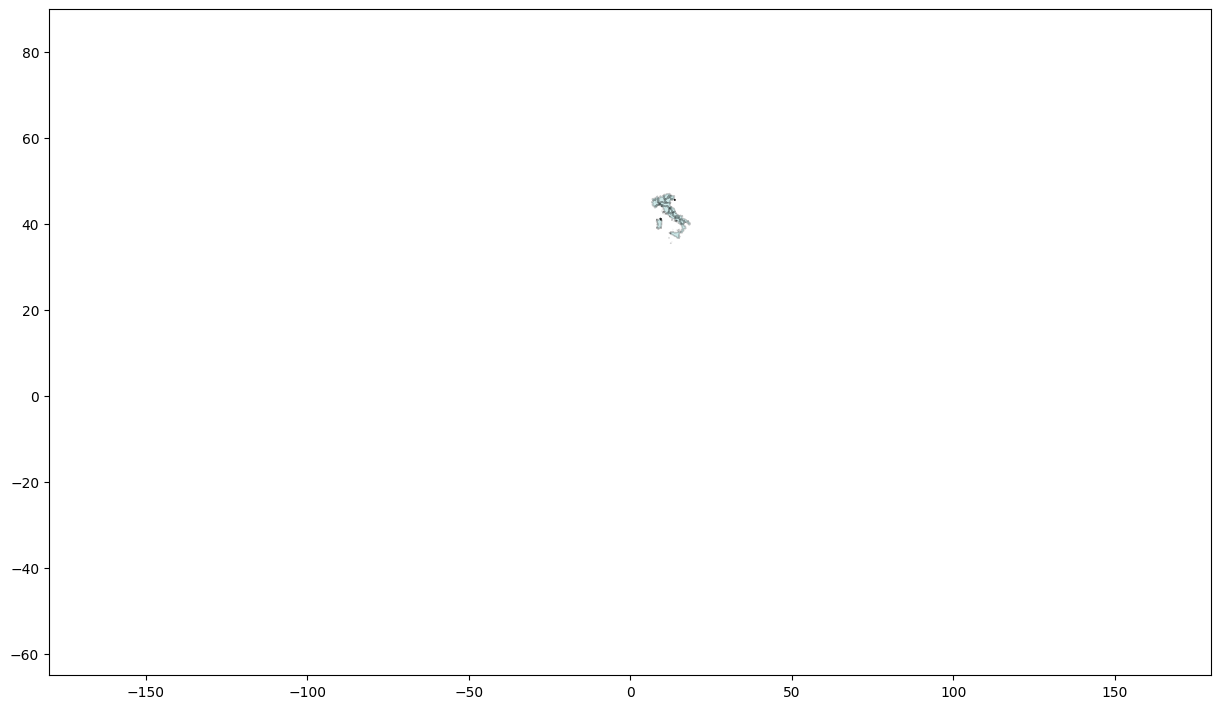

In [75]:
### Draw the world map with the countries

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html

# If we want to exclude the Antarctic region
#countries.clip([-180.0, -10.0, 180.0, 90.0])

ax = countries.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(15,10))

# If we want to exclude the Antarctic region
ax.set_xlim(-180,180)
ax.set_ylim(-65, 90)


plt.show()



In [76]:
### spatial join : if POINT is inside REGION -> join 
# per person we add the country of birth
pgr_reg_countries = pgr_reg.sjoin(countries)
pgr_reg_countries.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,reg_name_left,reg_istat_code_num_left,reg_istat_code_left,index_right,reg_name_right,reg_istat_code_num_right,reg_istat_code_right
531,http://www.wikidata.org/entity/Q677102,Michele De Pietro,1884,maschio,Cursi,POINT (18.31667 40.15),http://www.wikidata.org/entity/Q52136,1880-1889,Puglia,16,16,15,Puglia,16,16
369,http://www.wikidata.org/entity/Q3848440,Mario Cevolotto,1887,maschio,Treviso,POINT (12.24222 45.67222),http://www.wikidata.org/entity/Q5475,1880-1889,Veneto,5,05,4,Veneto,5,05
60,http://www.wikidata.org/entity/Q1398773,Fausto Gullo,1887,maschio,Catanzaro,POINT (16.5875 38.91),http://www.wikidata.org/entity/Q3883,1880-1889,Calabria,18,18,17,Calabria,18,18


In [77]:
### Liyt of column names
pgr_reg_countries.columns

Index(['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry',
       'uriPlace', 'periods', 'reg_name_left', 'reg_istat_code_num_left',
       'reg_istat_code_left', 'index_right', 'reg_name_right',
       'reg_istat_code_num_right', 'reg_istat_code_right'],
      dtype='object')

### Clean up gender variable

In [78]:
pgr_reg_countries.groupby(by='gender').size()

gender
femmina     59
maschio    502
dtype: int64

In [79]:
### Limit to female/male for statistic treatment
pgr_reg_countries=pgr_reg_countries[pgr_reg_countries.gender.isin(['femmina', 'maschio'])]

In [80]:
pgr_reg_countries.groupby(by='gender').size()

gender
femmina     59
maschio    502
dtype: int64

### Prepare the data for the bivariate analysis, cf. challenge da3

In [81]:
### Create columns for long / lat
pgr_reg_countries['long'] = pgr_reg_countries['geometry'].x
pgr_reg_countries['lat'] = pgr_reg_countries['geometry'].y
pgr_reg_countries.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,reg_name_left,reg_istat_code_num_left,reg_istat_code_left,index_right,reg_name_right,reg_istat_code_num_right,reg_istat_code_right,long,lat
234,http://www.wikidata.org/entity/Q3677447,Cipriano Facchinetti,1889,maschio,Campobasso,POINT (14.6684 41.561),http://www.wikidata.org/entity/Q3497,1880-1889,Molise,14,14,13,Molise,14,14,14.668400,41.561000
531,http://www.wikidata.org/entity/Q677102,Michele De Pietro,1884,maschio,Cursi,POINT (18.31667 40.15),http://www.wikidata.org/entity/Q52136,1880-1889,Puglia,16,16,15,Puglia,16,16,18.316667,40.150000
238,http://www.wikidata.org/entity/Q3680782,Umberto Merlin,1885,maschio,Rovigo,POINT (11.794 45.0809),http://www.wikidata.org/entity/Q6572,1880-1889,Veneto,5,05,4,Veneto,5,05,11.794000,45.080900
511,http://www.wikidata.org/entity/Q599670,Antonio Azara,1883,maschio,Tempio Pausania,POINT (9.10436 40.90148),http://www.wikidata.org/entity/Q13645,1880-1889,Sardegna,20,20,19,Sardegna,20,20,9.104361,40.901479
231,http://www.wikidata.org/entity/Q366104,Adone Zoli,1887,maschio,Cesena,POINT (12.23333 44.13333),http://www.wikidata.org/entity/Q6662,1880-1889,Emilia-Romagna,8,08,7,Emilia-Romagna,8,08,12.233333,44.133333


### Group by regions and periods

In [84]:
reg_per=pgr_reg.groupby(['reg_istat_code_num', 'reg_name', 'periods'], observed=True, as_index=False).size()
reg_per.head(3)

,reg_istat_code_num,reg_name,periods,size
0,1,Piemonte,1880-1889,1
1,1,Piemonte,1890-1899,4
2,1,Piemonte,1900-1909,1


In [94]:
print(geom_reg_per.columns)

Index(['reg_istat_code_num', 'reg_name_x', 'periods', 'size', 'reg_name_y',
       'reg_istat_code', 'geometry'],
      dtype='object')


In [95]:
### Merge with world to get polygons
geom_reg_per=pd.merge(reg_per, world, left_on='reg_istat_code_num', right_on='reg_istat_code_num')
geom_reg_per=geom_reg_per.drop(['reg_name_y','size','size'], axis=1)
geom_reg_per.columns=['reg_istat_code_num', 'name','periods','number','geometry']
geom_reg_per.head(2)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1880-1889,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,1,Piemonte,1890-1899,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [96]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1880-1889,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,1,Piemonte,1890-1899,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [97]:
print(len(grp_geo))

148


In [99]:
### Tableau de contingence
X = "reg_name"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
pv_per_reg

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto,Total
periods,,,,,,,,,,,,,,,,,,,,
1880-1889,0,0,2,1,5,0,3,1,2,0,1,1,2,1,0,1,2,0,4,26
1890-1899,1,0,0,3,3,2,3,0,3,3,0,4,0,1,3,2,0,0,1,29
1900-1909,1,0,1,6,1,2,5,3,8,1,0,1,1,1,5,3,1,0,5,45
1910-1919,0,0,1,1,4,0,6,3,9,0,1,2,3,1,4,2,0,1,4,42
1920-1929,2,2,2,13,4,3,16,4,13,4,1,6,5,3,6,7,2,2,4,99
1930-1939,2,0,5,16,7,2,10,2,15,1,0,6,5,6,3,2,0,3,5,90
1940-1949,1,0,2,6,3,1,9,3,19,0,0,7,5,0,8,4,0,0,8,76
1950-1959,0,1,2,3,8,0,16,2,8,0,1,5,4,1,4,2,0,2,6,65
1960-1969,0,0,0,6,4,1,4,3,10,0,1,4,3,1,5,3,0,0,1,46


In [100]:
### Table translation
df_t = pv_per_reg.T

In [101]:
df_t[df_t.Total > 200]

periods,1880-1889,1890-1899,1900-1909,1910-1919,1920-1929,1930-1939,1940-1949,1950-1959,1960-1969,1970-1979,1980-1989,Total
reg_name,,,,,,,,,,,,
Total,26,29,45,42,99,90,76,65,46,28,9,555


In [102]:
print(list(df_t.index))

['Abruzzo', 'Basilicata', 'Calabria', 'Campania', 'Emilia-Romagna', 'Friuli-Venezia Giulia', 'Lazio', 'Liguria', 'Lombardia', 'Marche', 'Molise', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Toscana', 'Trentino-Alto Adige/Südtirol', 'Umbria', 'Veneto', 'Total']


In [103]:
grp_geo.head(1)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1880-1889,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [104]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1880-1889,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,1,Piemonte,1890-1899,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [105]:
print(grp_geo.crs)

EPSG:4326


In [106]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.8)
)

In [107]:
grp_geo=grp_geo.sort_values(by='periods')

In [108]:
max = grp_geo.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    grp_geo,
    geojson=grp_geo.__geo_interface__,
    locations=grp_geo.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='Blues',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    #map_style='white-bg',
    hover_name='name',
    center={'lat': 47, 'lon': 8.5},
    height=800,
    width=1000,
    animation_frame="periods",
    #title="Temporal evolution of birth regions"

)


fig.update_layout(
    #mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 2000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20



f_address = "interactive_images/birth_periods_regions_choropleth.html"
fig.write_html(f_address)
# Show the plot
# fig.show()

### Group by regions and periods: only female persons

In [109]:
reg_per=pgr_reg[pgr_reg.gender=='femmina'].groupby(['reg_istat_code_num', 'reg_name', 'periods'], observed=True, as_index=False).size()
reg_per.head(3)

,reg_istat_code_num,reg_name,periods,size
0,1,Piemonte,1920-1929,1
1,1,Piemonte,1930-1939,1
2,1,Piemonte,1940-1949,2


In [110]:
### Merge with world to get polygons
geom_reg_per=pd.merge(reg_per, world, left_on='reg_istat_code_num', right_on='reg_istat_code_num')
geom_reg_per=geom_reg_per.drop(['reg_name_y','size','size'], axis=1)
geom_reg_per.columns=['reg_istat_code_num', 'name','periods','number','geometry']
geom_reg_per.head(2)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1920-1929,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,1,Piemonte,1930-1939,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [111]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1920-1929,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,1,Piemonte,1930-1939,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [112]:
print(len(grp_geo))

44


In [113]:
### Tableau de contingence
X = "reg_name"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
# pv_per_reg

In [115]:
### Table translation
df_t = pv_per_reg.T

In [116]:
# df_t[df_t.Total > 200]

In [117]:
print(list(df_t.index))

['Abruzzo', 'Basilicata', 'Calabria', 'Campania', 'Emilia-Romagna', 'Friuli-Venezia Giulia', 'Lazio', 'Liguria', 'Lombardia', 'Marche', 'Molise', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Toscana', 'Trentino-Alto Adige/Südtirol', 'Umbria', 'Veneto', 'Total']


In [118]:
grp_geo.head(1)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1920-1929,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [119]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,reg_istat_code_num,name,periods,number,geometry
0,1,Piemonte,1920-1929,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."
1,1,Piemonte,1930-1939,01,"POLYGON ((7.13605 45.27996, 7.13601 45.2804, 7..."


In [120]:
print(grp_geo.crs)

EPSG:4326


In [121]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.8)
)

In [122]:
grp_geo=grp_geo.sort_values(by='periods')

In [123]:
max = grp_geo.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    grp_geo,
    geojson=grp_geo.__geo_interface__,
    locations=grp_geo.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='RdPu',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    #map_style='white-bg',
    hover_name='name',
    center={'lat': 47, 'lon': 8.5},
    height=800,
    width=1000,
    animation_frame="periods",
    #title="Temporal evolution of birth regions"

)


fig.update_layout(
    #mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 2000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20



f_address = "interactive_images/birth_periods_regions_choropleth_female.html"
fig.write_html(f_address)
# Show the plot
# fig.show()